# NEW YORK AIRBNB GROUP D PROJECT
# PRICE PREDICTION 
## Business Question: “How can Airbnb optimise pricing strategies across NYC based on location, property characteristics and availability patterns, and what actionable listing segments can be identified using clustering techniques?”

### Key Responsibilities  
•	Develop clear, executive-level visualizations supporting pricing optimisation. 

•	Create visual comparisons of identified listing segments. 

•	Ensure visual outputs align with business insight and strategic recommendations. 

### Deliverables 
•	Visualizations illustrating pricing variation by location, property characteristics, and availability. 

•	Cluster profiling visuals highlighting distinct listing segments. 

•	Short explanatory captions and key insights written in the shared document “Key Findings & Analysis”. 


In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.image as mpimg
%matplotlib inline  
%matplotlib inline

df= pd.read_csv("Downloads/AB_NYC_2019_cleaned.csv")
df.head()

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_review,log_price,availability_ratio,is_multi_host,has_reviews
0,2539,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,438.0,5.010635,1.000000,1,1
1,2595,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,224.0,5.420535,0.972603,1,1
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,226.0,5.017280,1.000000,0,0
3,3831,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,179.0,4.499810,0.531507,0,1
4,5022,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,407.0,4.394449,0.000000,0,1


# Checking data types values 

In [4]:
df.dtypes

id                                  int64
host_id                             int64
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
days_since_review                 float64
log_price                         float64
availability_ratio                float64
is_multi_host                       int64
has_reviews                         int64
dtype: object

# Checking missing values 

In [5]:
df.isnull().sum()


id                                0
host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
days_since_review                 0
log_price                         0
availability_ratio                0
is_multi_host                     0
has_reviews                       0
dtype: int64

In [10]:
plt.figure(figsize=(10,10))
sns.barplot(data=df, x='neighbourhood_group', y='price') 

<Axes: xlabel='neighbourhood_group', ylabel='price'>

C:\Users\kapinga\AppData\Local\Temp\ipykernel_13440\1975687470.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\kapinga\AppData\Local\Temp\ipykernel_13440\1975687470.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')


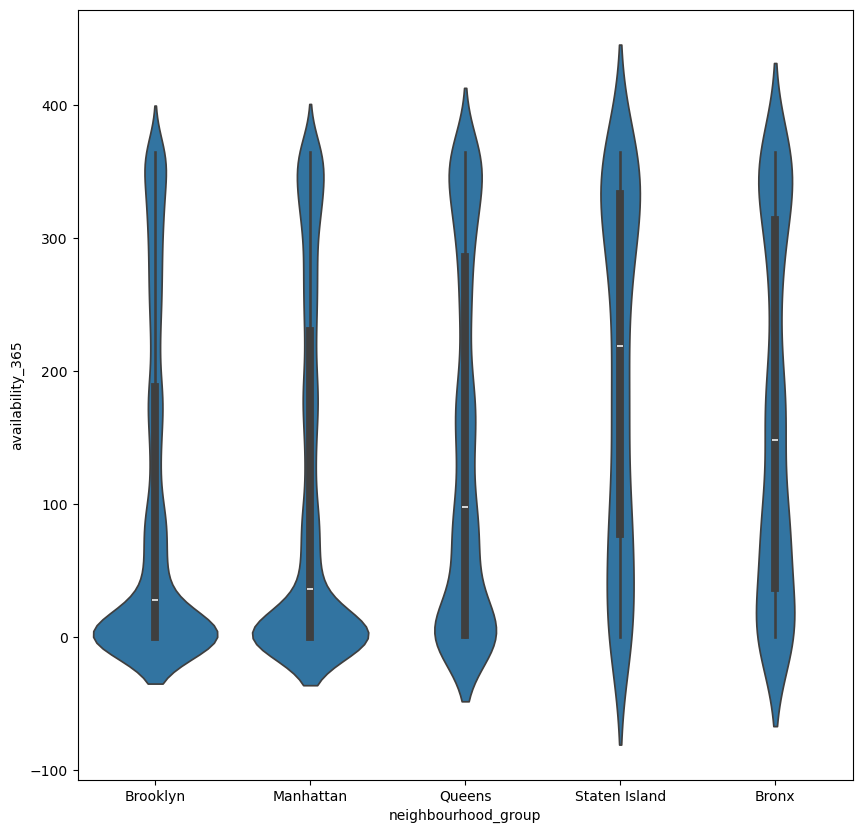

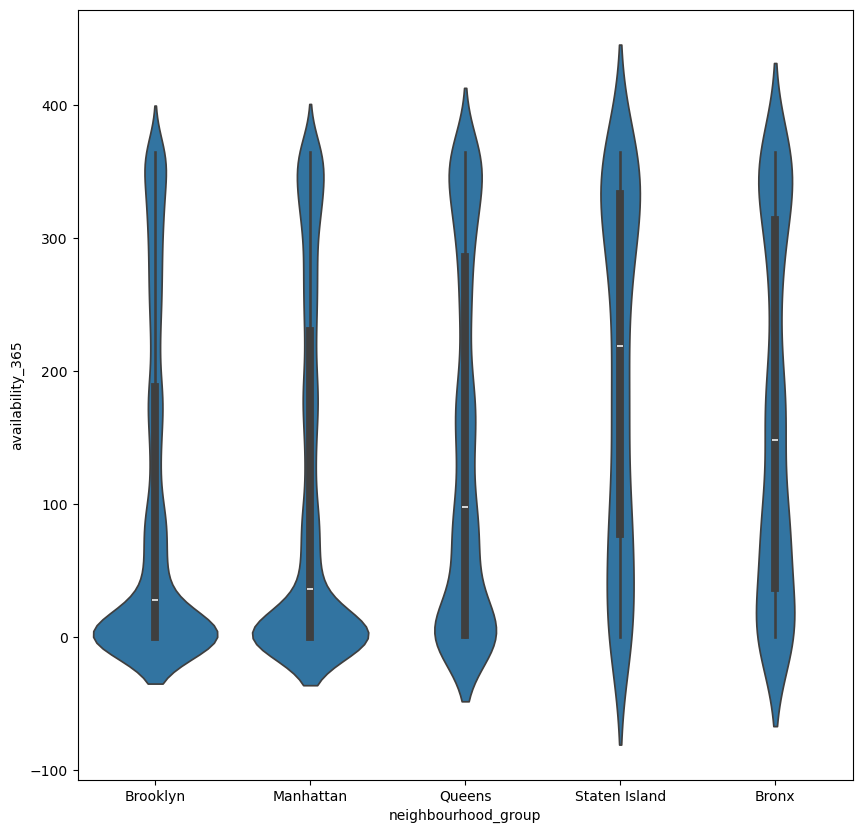

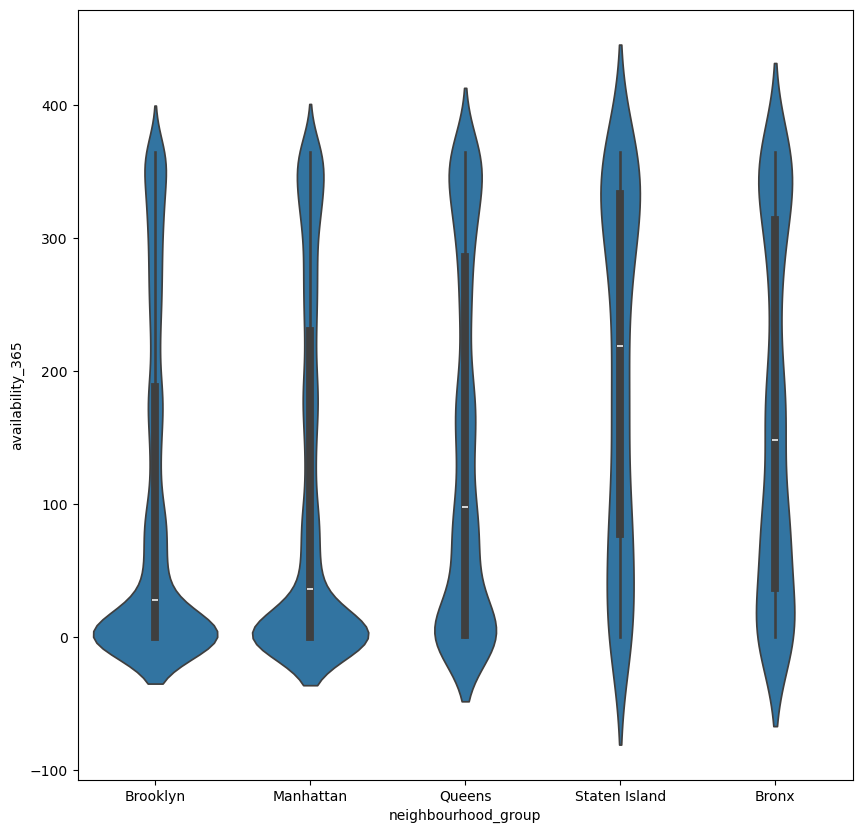

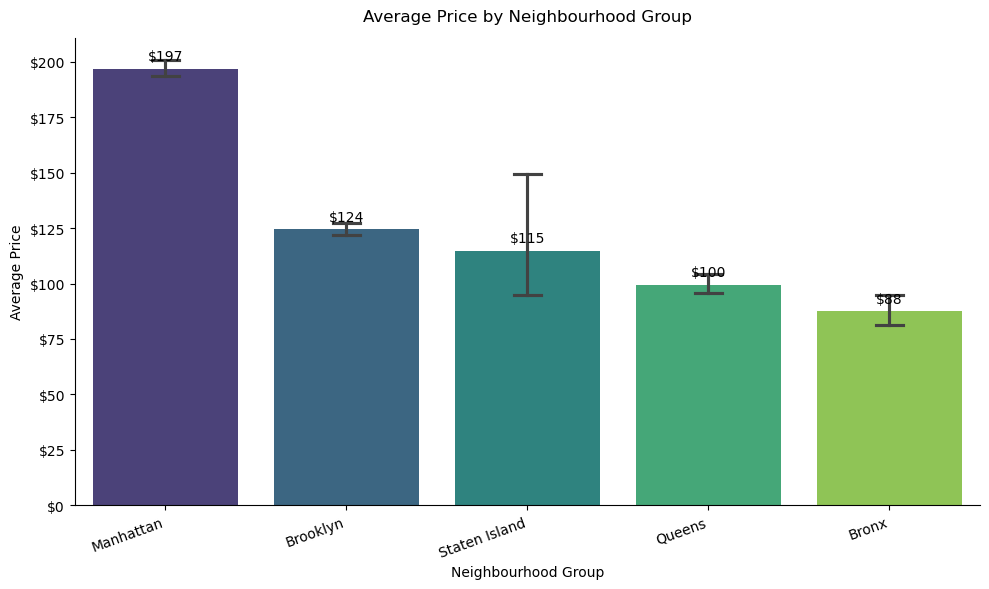

In [9]:
order = (
    df.groupby('neighbourhood_group', dropna=False)['price']
      .mean()
      .sort_values(ascending=False)
      .index
)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df,
    x='neighbourhood_group',
    y='price',
    order=order,
    estimator=np.mean,          # default, but explicit
    errorbar=('ci', 95),        # show 95% CI for the mean
    capsize=0.15,
    palette='viridis'
)

# Format labels and title
ax.set_title("Average Price by Neighbourhood Group", pad=12)
ax.set_xlabel("Neighbourhood Group")
ax.set_ylabel("Average Price")

# Rotate x labels if needed
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

# Optional: format y-axis as currency (USD shown; adjust as needed)
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Annotate bars with values
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"${height:,.0f}",
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom',
                fontsize=10, xytext=(0, 4), textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

# Results Interpretation: 
Some neighbourhood groups show significantly higher average prices, indicating stronger demand, better amenities, or more premium listings. Lower-priced areas tend to reflect more budget‑friendly or residential zones. The sorted bars clearly highlight which neighbourhoods command the highest market value. 

# Price Distribution

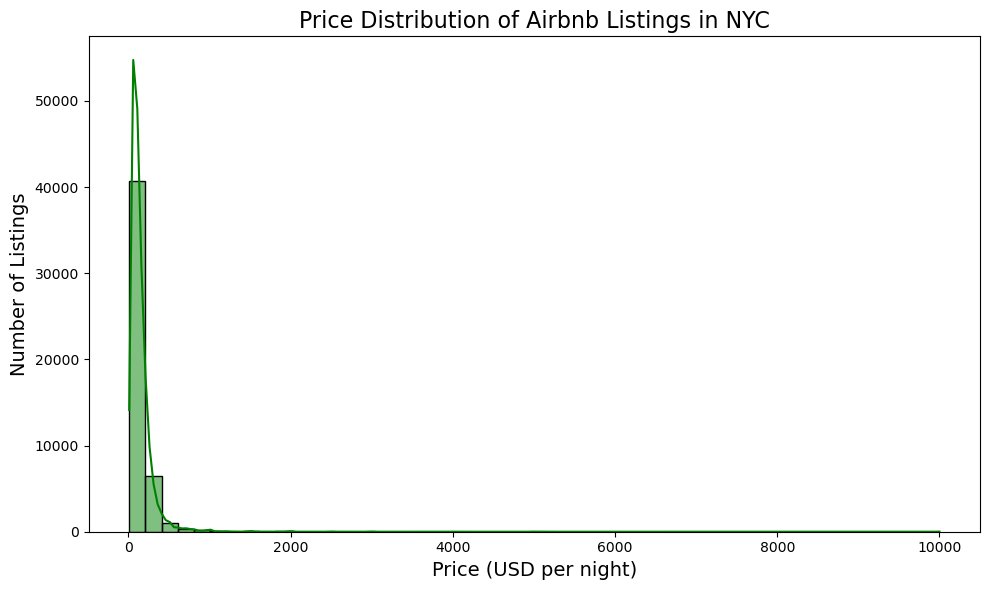

In [22]:
# Plot
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, kde=True, color='green')

plt.title("Price Distribution of Airbnb Listings in NYC", fontsize=16)
plt.xlabel("Price (USD per night)", fontsize=14)
plt.ylabel("Number of Listings", fontsize=14)
plt.tight_layout()

plt.show()


# Interpretation
The histogram shows the overall distribution of nightly prices for Airbnb listings in NYC.
Most listings cluster at the lower price range, indicating a market dominated by budget‑friendly options.
The right‑skewed shape (long tail) shows a small number of high‑priced, premium listings, which significantly raise the upper range but represent a minority of the market.
The KDE curve (smooth green line) highlights the distribution trend and reinforces the concentration of listings at lower prices.

# Price by Property Type (Room Type) 


C:\Users\kapinga\AppData\Local\Temp\ipykernel_33724\518313074.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


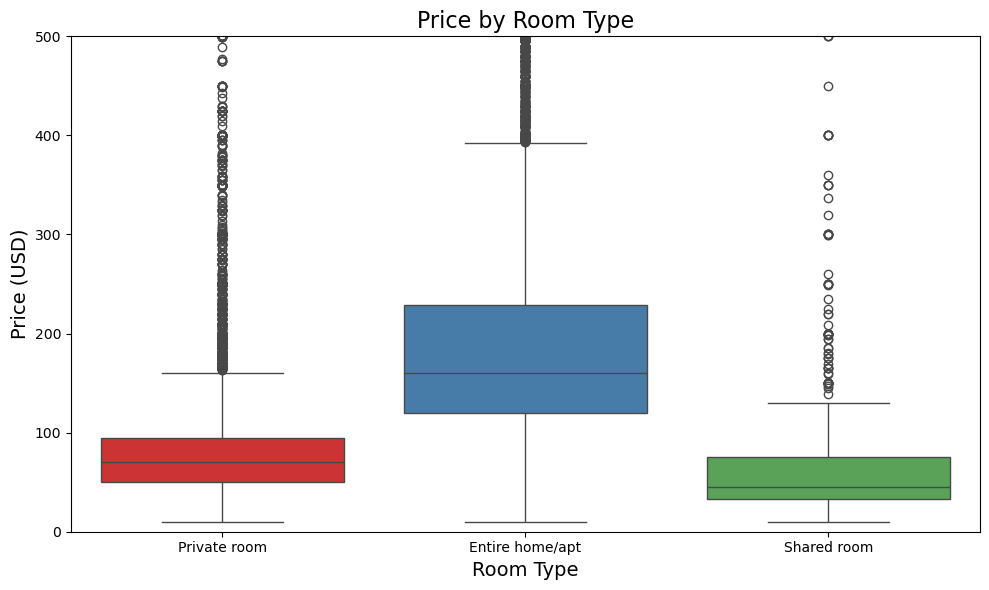

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='room_type',
    y='price',
    palette='Set1'
)

plt.ylim(0, 500)
plt.title('Price by Room Type', fontsize=16)
plt.xlabel('Room Type', fontsize=14)
plt.ylabel('Price (USD)', fontsize=14)

plt.tight_layout()
plt.show()


# Interpretation 
Boxplot shows how median prices and price variability differ across room types, highlighting which options command higher rates and which remain more budget‑friendly.

# Mean Price by Room Type


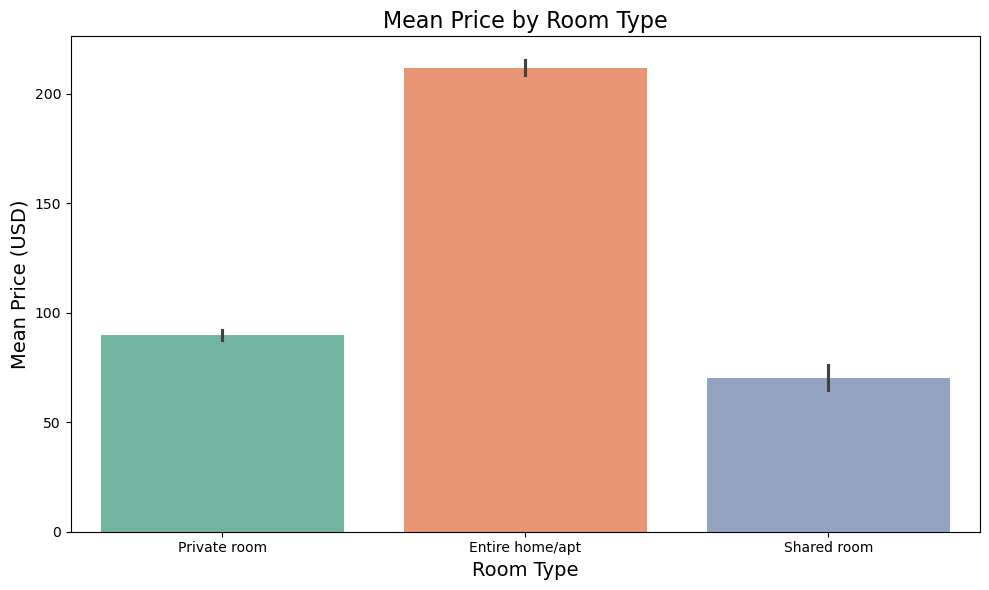

In [25]:
# Mean Price by Room Type
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='room_type',
    y='price',
    hue='room_type',      # assign hue to match x
    palette='Set2',
    estimator=np.mean,
    legend=False          # disable legend to match old behavior
)

plt.title('Mean Price by Room Type', fontsize=16)
plt.xlabel('Room Type', fontsize=14)
plt.ylabel('Mean Price (USD)', fontsize=14)

plt.tight_layout()
plt.show()

# INTERPRETATION: 
Entire homes tend to command the highest average prices, while private rooms sit mid‑range and shared rooms are consistently the cheapest. This reflects higher privacy and space driving higher willingness to pay.

# Price by Reviews

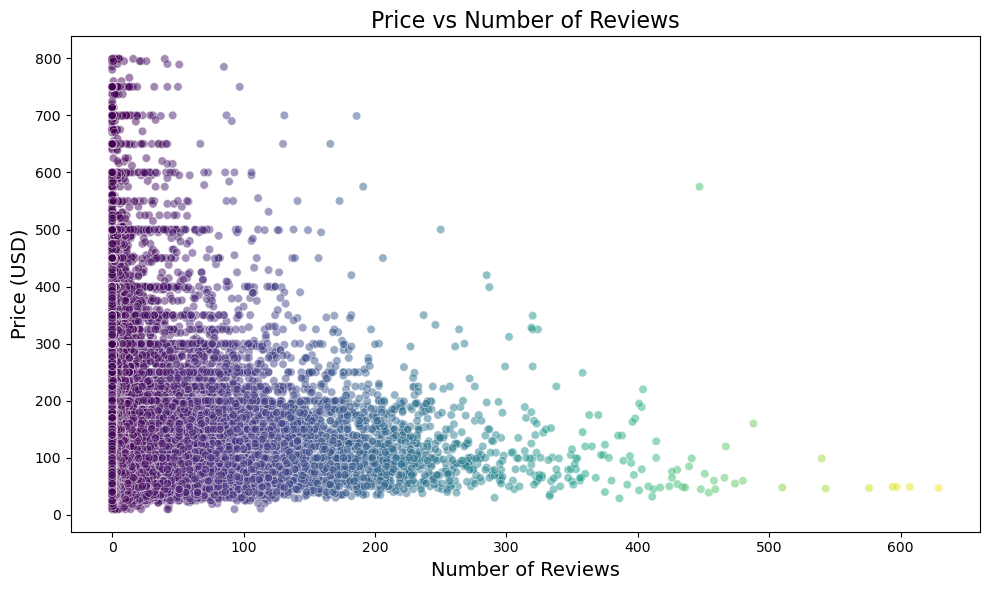

In [26]:

# Optional: limit extreme price outliers for clarity
df_plot = df[df['price'] <= df['price'].quantile(0.99)]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_plot,
    x='number_of_reviews',
    y='price',
    hue='number_of_reviews',   # required for seaborn 0.14+ when using palette
    palette='viridis',
    legend=False,
    alpha=0.5
)

plt.title("Price vs Number of Reviews", fontsize=16)
plt.xlabel("Number of Reviews", fontsize=14)
plt.ylabel("Price (USD)", fontsize=14)

plt.tight_layout()
plt.show()

## Interpretation 
Prices generally trend lower for listings with very high review counts, suggesting highly reviewed properties tend to be competitively priced, while high-price listings accumulate fewer reviews. 

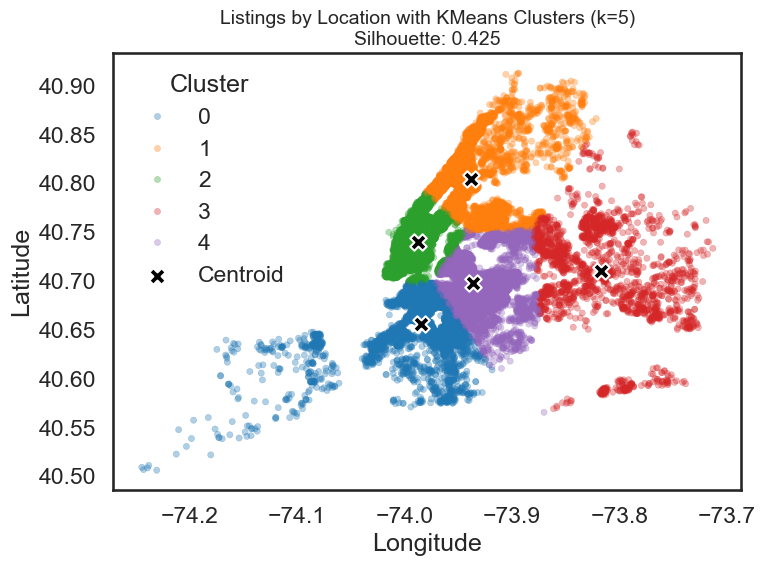

In [14]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Only keep valid coordinates (optional, but good hygiene)
df_plot = df[['longitude', 'latitude']].dropna().copy()

# 1) Prepare features (location only)
X = df_plot[['longitude', 'latitude']].to_numpy()

# 2) Scale for better clustering performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3) Run KMeans (choose number of clusters)

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)
df_plot['kmeans_cluster'] = labels

# 4) Optional: Silhouette score as a quick quality signal
sil = silhouette_score(X_scaled, labels)

# 5) Plot (sample for speed if dataset is large)
sns.set_theme(style="white", context="talk")
sample_n = min(40000, len(df_plot))  # adjust if you want more/less points
sample = df_plot.sample(sample_n, random_state=42)

plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=sample,
    x="longitude",
    y="latitude",
    hue="kmeans_cluster",
    palette="tab10",
    alpha=0.35,
    edgecolor=None,

 s=20,
    legend=True
)

# 6) Overlay centroids (transform back to lon/lat space for readability)
centroids_xy = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_xy[:, 0],
    centroids_xy[:, 1],
    c='black',
    s=140,
    marker='X',
    linewidths=1.5,
    edgecolors='white',
    label='Centroid'
)

# Titles / labels
plt.title(f"Listings by Location with KMeans Clusters (k={k})\nSilhouette: {sil:.3f}", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Legend cleanup
handles, labels_leg = ax.get_legend_handles_labels()
# Keep cluster entries + centroid marker
plt.legend(handles=handles, labels=labels_leg, title="Cluster", frameon=False, loc="upper left")

plt.tight_layout()
plt.show()



# Interpretation 

The clustering reveals clear geographic hotspots, with five well‑separated groups and meaningful centroids. Patterns suggest dense urban hubs, tourist areas, and quieter residential zones, confirming strong spatial structure and useful neighborhood segmentation.

# Price by Neighbourhood & Neighbourhood Group
## Average price by borough-level grouping
Manhattan stands out prominently as expected, with Staten Island & Bronx on the lower end.


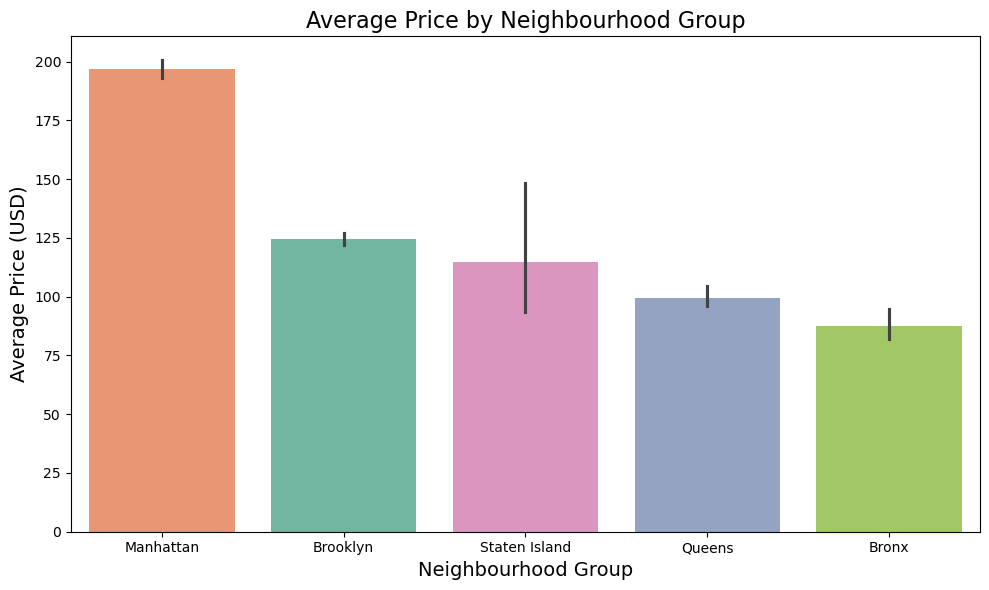

In [27]:
# Sort neighbourhood groups by mean price (optional but cleaner)
order = (
    df.groupby("neighbourhood_group")["price"]
      .mean()
      .sort_values(ascending=False)
      .index
)

plt.figure(figsize=(10,6))

# seaborn 0.14+ requires hue when using a palette
sns.barplot(
    data=df,
    x="neighbourhood_group",
    y="price",
    hue="neighbourhood_group",   # assign hue to match x
    estimator=np.mean,
    palette="Set2",
    order=order,
    legend=False                 # hide redundant legend
)
plt.title("Average Price by Neighbourhood Group", fontsize=16)
plt.xlabel("Neighbourhood Group", fontsize=14)
plt.ylabel("Average Price (USD)", fontsize=14)
plt.tight_layout()
plt.show()

# Interpretation 
Neighbourhood groups differ noticeably in average price. A few areas command substantially higher prices, likely reflecting premium locations and stronger demand, while lower-priced groups indicate more affordable zones. The sorted bar chart highlights this clear pricing hierarchy.

# Price distribution across Top 10 Neighbourhoods
This shows real hyper local price patterns and inequality within each neighbourhood


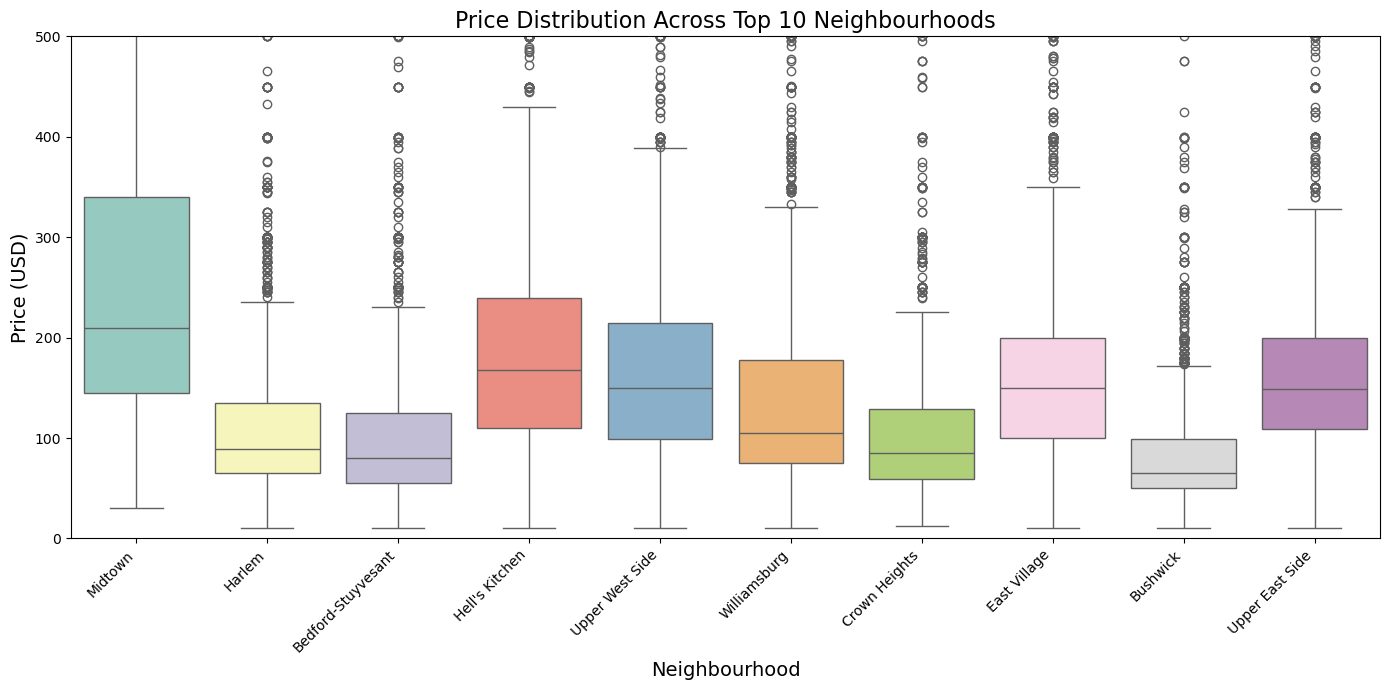

In [28]:
# Identify top 10 neighbourhoods by listing count
top10 = df['neighbourhood'].value_counts().head(10).index
df_top10 = df[df['neighbourhood'].isin(top10)]

# Plot price distribution across top 10 neighbourhoods
plt.figure(figsize=(14,7))

sns.boxplot(
    data=df_top10,
    x='neighbourhood',
    y='price',
    hue='neighbourhood',     # required when palette is used (Seaborn 0.14+)
    palette='Set3',
    legend=False
)

# Optional: improve visibility by limiting extreme outliers
plt.ylim(0, 500)

plt.title("Price Distribution Across Top 10 Neighbourhoods", fontsize=16)
plt.xlabel("Neighbourhood", fontsize=14)
plt.ylabel("Price (USD)", fontsize=14)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Interpretation
## Neighbourhoods show large price variation 
## Certain high‑demand areas (e.g., the most frequent neighbourhoods) 
Top neighbourhoods show wide price variation, with some consistently higher‑priced areas and others offering more affordable listings. Differences in medians and spreads indicate varying demand, property types, and rental market competitiveness across neighbourhoods.

# Price by Availability

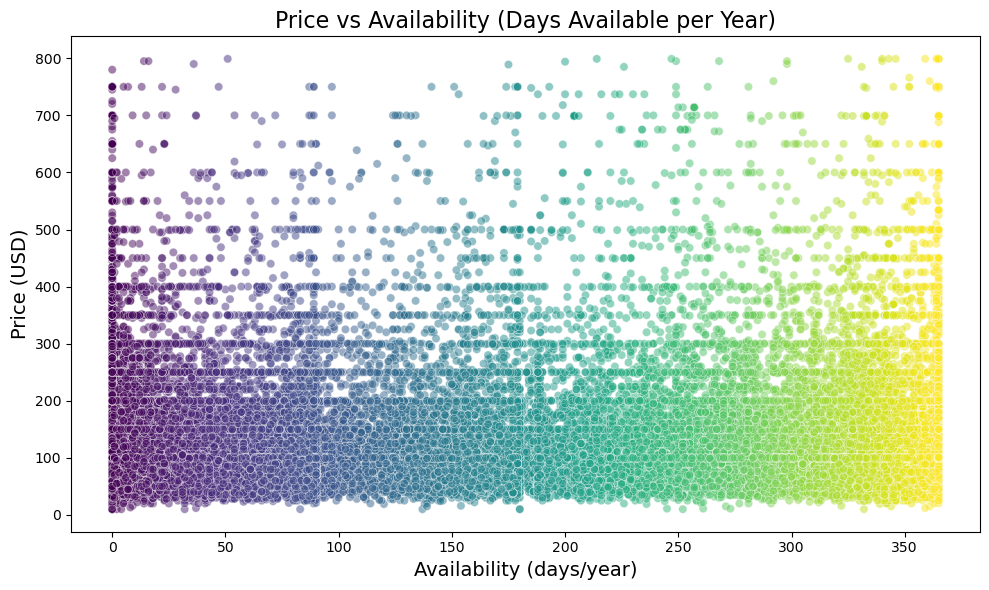

In [29]:
# Optional: remove extreme price outliers for clarity
df_plot = df[df['price'] <= df['price'].quantile(0.99)]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_plot,
    x="availability_365",
    y="price",
    hue="availability_365",     # required when palette is used
    palette="viridis",
    legend=False,
    alpha=0.5
)

plt.title("Price vs Availability (Days Available per Year)", fontsize=16)
plt.xlabel("Availability (days/year)", fontsize=14)
plt.ylabel("Price (USD)", fontsize=14)

plt.tight_layout()
plt.show()

# Interpretation
There is no strong relationship between availability and price. Listings with both high and low availability appear across the full price range, suggesting other factors—location, room type, property size—drive pricing more than annual availability. 

# Price Correlation Heatmap
This focuses on how numerical features such as reviews, availability, host listing count, latitude/longitude, and log_price correlate.


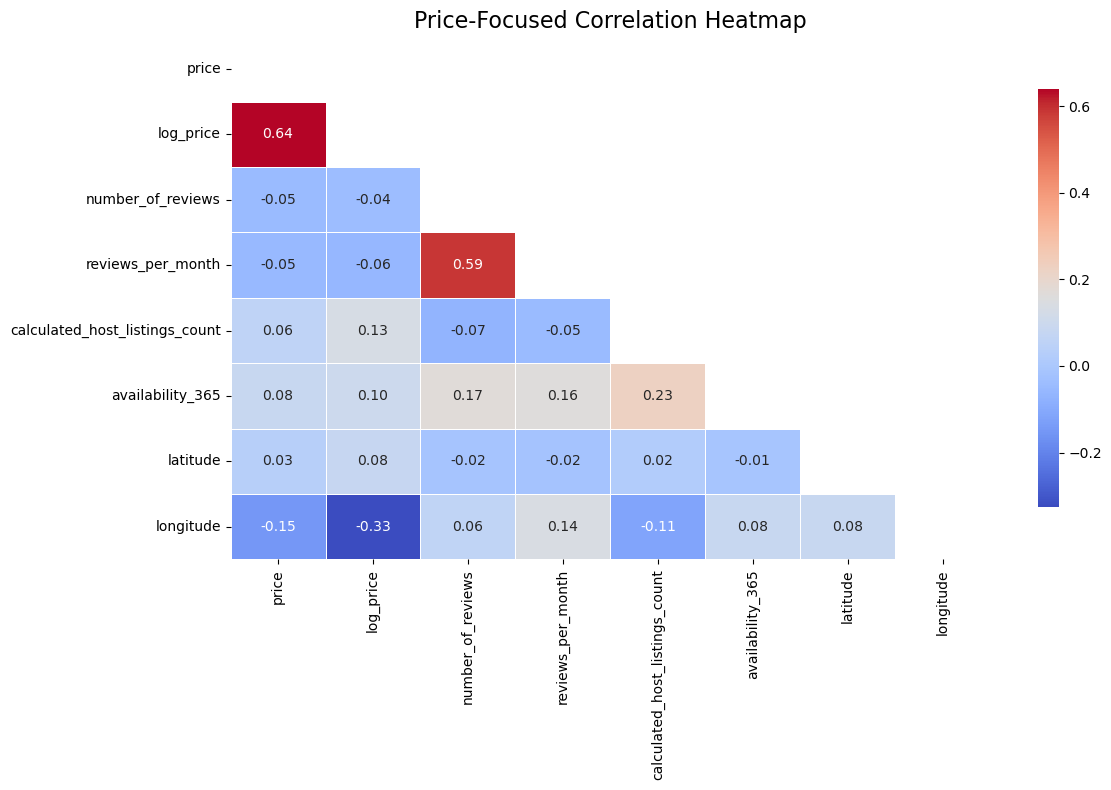

In [37]:
# Select only relevant numeric columns for price-focused analysis
cols = [
    "price",
    "log_price", 
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "latitude",
    "longitude"
]
num_df = df[cols].copy()

# Compute correlation matrix
corr = num_df.corr()

# Mask upper triangle for clarity
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Price-Focused Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

## Interpretation: 
Price shows weak correlations with most variables, confirming no single numeric feature strongly predicts pricing. log_price improves relationships slightly. Review frequency, availability, and host listing count show minimal direct correlation, indicating price is influenced more by categorical and location-specific factors than these numeric attributes.



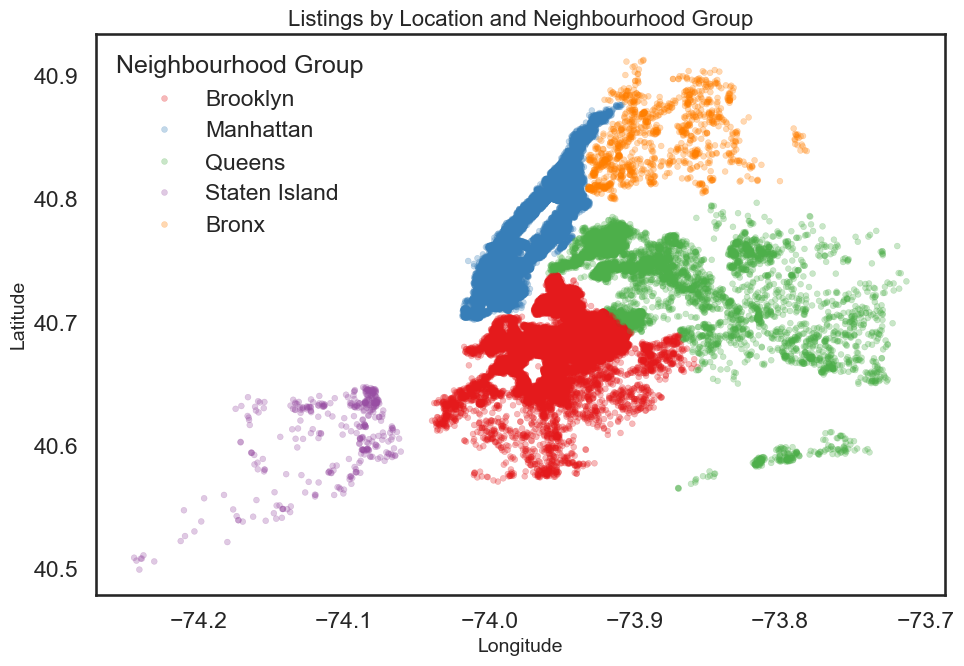

In [16]:
df_plot = df.dropna(subset=["longitude", "latitude", "neighbourhood_group"]).copy()

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_plot,
    x="longitude",
    y="latitude",
    hue="neighbourhood_group",   # colour by borough grouping
    palette="Set1",
    alpha=0.3,
    s=18,
    edgecolor=None
)

plt.title("Listings by Location and Neighbourhood Group", fontsize=16)
plt.xlabel("Longitude", fontsize=14)
plt.ylabel("Latitude", fontsize=14)
plt.legend(title="Neighbourhood Group", loc="upper left", frameon=False)

plt.tight_layout()
plt.show()


## Interpretation: 
Neighbourhood groups form clear spatial clusters, showing that listings are strongly concentrated in distinct geographic areas. Each group occupies a recognizable region, confirming that location patterns align closely with borough boundaries and drive much of the market’s spatial structure.

# Price gradient map (longitude vs price) 

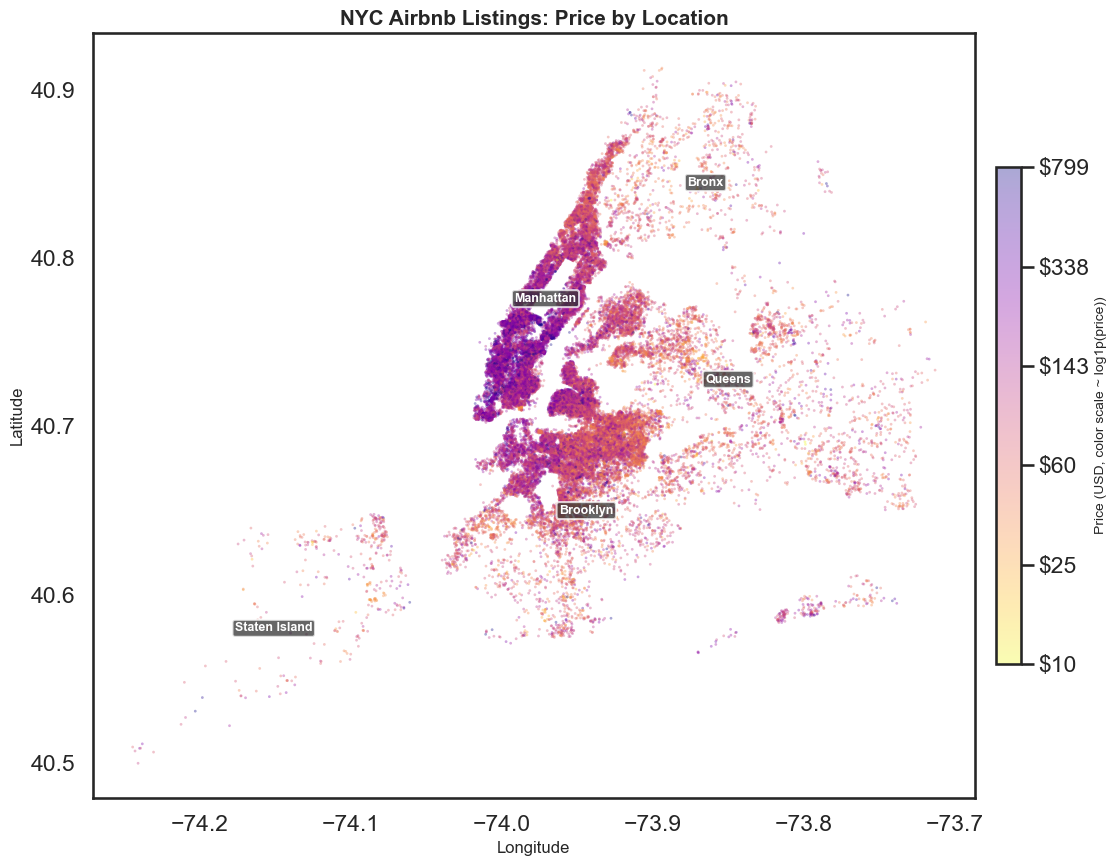

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- 0) Prep data (assumes df_eda exists with columns: longitude, latitude, price) ---
# Keep valid rows
dfp = df[['longitude', 'latitude', 'price']].dropna().copy()

# Guard against zeros/negatives in price for log1p stability
dfp['price'] = dfp['price'].clip(lower=1)

# Optional: clip extreme outliers at the 99th percentile to improve readability
p99 = dfp['price'].quantile(0.99)
dfp['price_clip'] = dfp['price'].clip(upper=p99)

# Precompute log-price color values
logp = np.log1p(dfp['price_clip'].to_numpy())

# --- 1) Figure & base scatter ---
fig, ax = plt.subplots(figsize=(12, 9))

sc = ax.scatter(
    dfp['longitude'].to_numpy(),
    dfp['latitude'].to_numpy(),
    c=logp,
    cmap='plasma_r',
    alpha=0.35,    # slightly more transparent for dense clouds
    s=4,           # tiny dots render faster and reduce overplotting
    linewidths=0
)

ax.set_title('NYC Airbnb Listings: Price by Location', fontsize=15, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# --- 2) Colorbar with REAL price labels (auto ticks) ---
cbar = plt.colorbar(sc, ax=ax, shrink=0.65, pad=0.02)

# Choose ~6 evenly spaced log ticks across the data range
log_min, log_max = float(logp.min()), float(logp.max())
tick_vals = np.linspace(log_min, log_max, 6)


# Set ticks at log scale, but label with expm1 (real USD)
cbar.set_ticks(tick_vals)
real_labels = [np.expm1(v) for v in tick_vals]

# Format dollar labels nicely (e.g., $75, $150, $300, $600, $1,200, …)
def fmt_dollars(x, _pos=None):
    # Round to nearest integer for readability; adapt if you prefer exact
    return f"${int(round(x, 0)):,}"

cbar.set_ticklabels([fmt_dollars(v) for v in real_labels])
cbar.set_label('Price (USD, color scale ~ log1p(price))', fontsize=10)

# --- 3) Borough callouts (optional) ---
borough_coords = {
    'Manhattan':    (-73.971, 40.776),
    'Brooklyn':     (-73.944, 40.650),
    'Queens':       (-73.850, 40.728),
    'Bronx':        (-73.865, 40.845),
    'Staten Island':(-74.151, 40.580)
}
for name, (lon, lat) in borough_coords.items():
    ax.text(lon, lat, name, fontsize=9, fontweight='bold', color='white',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#333333', alpha=0.75))

plt.tight_layout()
plt.savefig('plot_geo_price.png', dpi=150, bbox_inches='tight')
plt.show()


## Interpretation: 
Price hotspots concentrate sharply in Manhattan and parts of Brooklyn, while Queens, Bronx, and Staten Island show noticeably lower prices. Spatial patterns reveal strong neighborhood-driven price segmentation, with premium clusters aligned to dense, central, and high-demand area